# Heston — Method Comparison

| Method | Trainer | Notes |
|---|---|---|
| **Delta LSMC** | — | Regression-based delta baseline |
| **Delta CF** | — | Exact Heston delta (slow) |
| **DH** | DeepHedging | Plain MLP |
| **DH-PAF** | DeepHedging | PAF embedding |
| **DH-PnL** | DeepHedging | MLP + running P&L feature |
| **DH-PAF-PnL** | DeepHedging | PAF + P&L |
| **DH-SAC** | SAC | Entropy regularisation |
| **DH-Deviation** | Deviation | Net predicts δ − δ_BSM, Adam |
| **DH-Deviation-KFAC** | Deviation | Same, K-FAC natural-gradient optimiser |
| **DH-Deviation-Muon** | Deviation | Same, Muon (Newton-Schulz orthogonalised updates) |

## 0. Setup

In [1]:
import os
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.samplers      import HestonSampler
from src.metrics       import SoftMin
from src.backtest      import torch_backtest
from src.models        import ModelConfig
from src.trainers      import (TrainerConfig, DeepHedgingTrainer, SACTrainer,
                               DeviationTrainer)
from src.deltas        import (LSMCDeltaHedger, HestonCFDeltaHedger,
                               HestonMVDeltaHedger)
from src.logging_utils import save_log

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


## 1. Parameters

In [2]:
# ── market ────────────────────────────────────────────────
S0    = 100.0
v0    = 0.04
r     = 0.01
kappa = 2.0
theta = 0.04
xi    = 0.1
rho   = -0.7
T     = 1.0
N     = 30
K     = 100.0
cost  = 1e-3
a     = 1.0

# ── training ──────────────────────────────────────────────
M_train  = 3_000
M_val    = 5_000   # validation paths (used for early stopping & best model)
M_test   = 5_000   # held-out test paths (evaluated once at the end)
n_epochs = 10_000
log_every           = 200
early_stop_patience = 100  # val checks without improvement → stop
lr                  = 1e-3

RESULTS_DIR = 'results_heston_cf_mv_copy3'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── paths ─────────────────────────────────────────────────
sampler = HestonSampler(
    S0=S0, v0=v0, r=r, kappa=kappa,
    theta=theta, xi=xi, rho=rho, T=T, N=N
)

np.random.seed(42)
paths_val    = sampler.sample(M_val)
paths_test   = sampler.sample(M_test)
paths_val_t  = torch.tensor(paths_val,  dtype=torch.float32, device=DEVICE)
paths_test_t = torch.tensor(paths_test, dtype=torch.float32, device=DEVICE)

results = {}  # name -> {pnl, fees, log}

## 2. Helpers

In [3]:
def softmin_np(pnl: np.ndarray, a: float = a) -> float:
    return float(np.log(np.exp(-a * pnl).mean()) / a)

def sync_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def _rectangular_log(rows: list[dict]) -> list[dict]:
    keys = []
    for row in rows:
        for key in row.keys():
            if key not in keys:
                keys.append(key)
    return [{key: row.get(key, float('nan')) for key in keys} for row in rows]

def record(name: str, pnl: np.ndarray, fees: np.ndarray,
           log: list | None = None, elapsed: float | None = None):
    log = [] if log is None else log
    results[name] = {'pnl': pnl, 'fees': fees, 'log': log, 'elapsed': elapsed}
    elapsed_msg = '' if elapsed is None else f"  elapsed={elapsed:>7.2f}s"
    print(f"  {name:<22}  SoftMin={softmin_np(pnl):>8.4f}  "
          f"mean={pnl.mean():>7.4f}  std={pnl.std():>6.4f}  "
          f"fees={fees.mean():>7.4f}" + elapsed_msg)

    test_summary = {
        "test_softmin": softmin_np(pnl),
        "mean_pnl": float(pnl.mean()),
        "std_pnl": float(pnl.std()),
        "fees_mean": float(fees.mean()),
        "elapsed": 0.0 if elapsed is None else float(elapsed),
    }
    if not log:
        summary = [{"epoch": 0, "val_loss": test_summary["test_softmin"],
                    **test_summary}]
    else:
        summary = [dict(e) for e in log]
        final = {"epoch": summary[-1].get("epoch", 0),
                 "val_loss": summary[-1].get("val_loss", float('nan')),
                 **test_summary}
        summary.append(final)
        summary = _rectangular_log(summary)
    save_log(summary, os.path.join(RESULTS_DIR, name.replace(' ', '_')))

def run_trainer(trainer, name: str):
    t0 = time.perf_counter()
    log = trainer.fit()
    pnl, fees = trainer.eval_on_test()
    sync_device()
    record(name, pnl, fees, log, elapsed=time.perf_counter() - t0)

def base_cfg(**overrides) -> TrainerConfig:
    """TrainerConfig with shared defaults."""
    defaults = dict(
        n_epochs=n_epochs, M_train=M_train,
        log_every=log_every,
        early_stop_patience=early_stop_patience,
        lr=lr,
    )
    return TrainerConfig(**{**defaults, **overrides})


def make_trainer(TrainerClass, cfg, **kwargs):
    return TrainerClass(
        cfg=cfg,
        sampler=sampler,
        paths_val_t=paths_val_t,
        paths_test_t=paths_test_t,
        device=DEVICE,
        risk_aversion=a,
        K=K,
        cost=cost,
        **kwargs
    )


print('Helpers ready.')


Helpers ready.


## 3. Delta LSMC baseline

In [4]:
lsmc = LSMCDeltaHedger(K=K, cost=cost)
t0 = time.perf_counter()
lsmc.fit(sampler.sample(10_000))
pnl, fees = lsmc.backtest(paths_test)
record('Delta LSMC', pnl, fees, elapsed=time.perf_counter() - t0)


  Delta LSMC              SoftMin=  9.9928  mean=-8.0929  std=2.1338  fees= 0.2147  elapsed=   0.07s


## 4. Delta CF baseline

In [5]:
M_test_cf = M_test
CF_N_QUAD = 512
CF_REF_PATHS = 20

cf = HestonCFDeltaHedger(
    K=K, r=r, kappa=kappa, theta=theta,
    xi=xi, rho=rho, T=T, N=N, cost=cost,
    n_quad=CF_N_QUAD, device=DEVICE, batch_size=8192,
)

# Validate the new torch/autograd delta against the old scipy finite-difference path.
S_check = np.array([80., 90., 100., 110., 120.])
v_check = np.array([0.02, 0.04, 0.04, 0.06, 0.08])
tau_check = 0.7
fast_check = cf._delta(S_check, v_check, tau_check)
ref_check = cf._delta_scipy(S_check, v_check, tau_check)
print(f"CF delta check: max_abs_diff={np.max(np.abs(fast_check - ref_check)):.3e} "
      f"with n_quad={CF_N_QUAD}")

# Time a small old-scipy slice and extrapolate to the full notebook baseline size.
cash_ref = np.zeros(CF_REF_PATHS)
delta_prev_ref = np.zeros(CF_REF_PATHS)
fees_ref = np.zeros(CF_REF_PATHS)
t0 = time.perf_counter()
for t in range(N):
    tau = T - t * T / N
    delta_t = cf._delta_scipy(paths_test[:CF_REF_PATHS, t, 0],
                              paths_test[:CF_REF_PATHS, t, 1], tau)
    d_delta = delta_t - delta_prev_ref
    cash_ref -= d_delta * paths_test[:CF_REF_PATHS, t, 0]
    fee_t = cost * np.abs(d_delta) * paths_test[:CF_REF_PATHS, t, 0]
    cash_ref -= fee_t
    fees_ref += fee_t
    delta_prev_ref = delta_t
cash_ref += delta_prev_ref * paths_test[:CF_REF_PATHS, -1, 0]
pnl_ref = cash_ref - np.clip(paths_test[:CF_REF_PATHS, -1, 0] - K, 0, None)
old_elapsed = time.perf_counter() - t0
print(f"Old scipy CF: {old_elapsed:.2f}s for {CF_REF_PATHS} paths; "
      f"linear extrapolation to {M_test_cf} paths = {old_elapsed * M_test_cf / CF_REF_PATHS:.1f}s")

# Full fast CF baseline.
t0 = time.perf_counter()
pnl, fees = cf.backtest(paths_test[:M_test_cf], verbose=False)
sync_device()
new_elapsed = time.perf_counter() - t0
record('Delta CF', pnl, fees, elapsed=new_elapsed)
print(f"Fast CF speedup vs extrapolated scipy: "
      f"{(old_elapsed * M_test_cf / CF_REF_PATHS) / new_elapsed:,.0f}x")


CF delta check: max_abs_diff=1.888e-06 with n_quad=512


Old scipy CF: 5.77s for 20 paths; linear extrapolation to 5000 paths = 1442.9s
  Delta CF                SoftMin=  9.5526  mean=-8.1252  std=1.4872  fees= 0.2263  elapsed=   0.18s
Fast CF speedup vs extrapolated scipy: 8,144x


## 4b. Delta MV / Bartlett baseline

In [6]:
mv = HestonMVDeltaHedger(
    K=K, r=r, kappa=kappa, theta=theta,
    xi=xi, rho=rho, T=T, N=N, cost=cost,
    n_quad=CF_N_QUAD, device=DEVICE, batch_size=8192,
)

t0 = time.perf_counter()
pnl, fees = mv.backtest(paths_test[:M_test_cf], verbose=False)
sync_device()
record('Delta MV', pnl, fees, elapsed=time.perf_counter() - t0)


  Delta MV                SoftMin=  9.4879  mean=-8.1392  std=1.3510  fees= 0.2243  elapsed=   0.18s


## 5. DH — plain MLP

In [7]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)))),
    'DH'
)

Trainable parameters: 4,545


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 1/10000 [00:00<1:01:47,  2.70it/s]

  0%|          | 3/10000 [00:00<23:43,  7.02it/s]  

  0%|          | 5/10000 [00:00<17:19,  9.61it/s]

...

100%|█████████▉| 9995/10000 [10:38<00:00, 15.75it/s]

100%|█████████▉| 9997/10000 [10:38<00:00, 15.77it/s]

100%|█████████▉| 9999/10000 [10:38<00:00, 15.78it/s]

100%|██████████| 10000/10000 [10:38<00:00, 15.66it/s]

  DH                      SoftMin= 10.1567  mean=-8.1178  std=2.4523  fees= 0.2290  elapsed= 638.49s


## 6. DH-PAF

In [8]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'))),
    'DH-PAF'
)

Trainable parameters: 4,289


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<13:35, 12.26it/s]

  0%|          | 4/10000 [00:00<12:51, 12.96it/s]

  0%|          | 6/10000 [00:00<12:19, 13.51it/s]

...

100%|█████████▉| 9996/10000 [11:49<00:00, 14.37it/s]

100%|█████████▉| 9998/10000 [11:49<00:00, 14.40it/s]

100%|██████████| 10000/10000 [11:49<00:00, 14.14it/s]

100%|██████████| 10000/10000 [11:49<00:00, 14.09it/s]

  DH-PAF                  SoftMin=  9.3076  mean=-8.1375  std=1.5780  fees= 0.2079  elapsed= 709.68s


## 7. DH-PnL

In [9]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp', hidden_dims=(64, 64)), use_pnl=True)),
    'DH-PnL'
)

Trainable parameters: 4,609


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<10:20, 16.11it/s]

  0%|          | 4/10000 [00:00<10:30, 15.85it/s]

  0%|          | 6/10000 [00:00<10:46, 15.46it/s]

...

100%|█████████▉| 9996/10000 [11:10<00:00, 15.23it/s]

100%|█████████▉| 9998/10000 [11:10<00:00, 14.98it/s]

100%|██████████| 10000/10000 [11:10<00:00, 14.56it/s]

100%|██████████| 10000/10000 [11:10<00:00, 14.91it/s]

  DH-PnL                  SoftMin=  9.8171  mean=-8.0966  std=2.0585  fees= 0.1947  elapsed= 670.92s


## 8. DH-PAF-PnL

In [10]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True)),
    'DH-PAF-PnL'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<12:45, 13.07it/s]

  0%|          | 4/10000 [00:00<12:18, 13.54it/s]

  0%|          | 6/10000 [00:00<12:27, 13.37it/s]

...

100%|█████████▉| 9996/10000 [12:26<00:00, 13.59it/s]

100%|█████████▉| 9998/10000 [12:26<00:00, 13.56it/s]

100%|██████████| 10000/10000 [12:26<00:00, 13.20it/s]

100%|██████████| 10000/10000 [12:26<00:00, 13.39it/s]

  DH-PAF-PnL              SoftMin= 19.6272  mean=-8.1204  std=5.3359  fees= 0.2852  elapsed= 746.66s


## 9. DH-SAC

In [11]:
run_trainer(
    make_trainer(SACTrainer,
                 base_cfg(model=ModelConfig(arch='paf'),
                          beta_start=0.05, beta_end=0.001)),
    'DH-SAC'
)

Trainable parameters: 4,289


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<12:01, 13.85it/s]

  0%|          | 4/10000 [00:00<12:44, 13.07it/s]

  0%|          | 6/10000 [00:00<12:20, 13.50it/s]

...

100%|█████████▉| 9996/10000 [12:14<00:00, 13.59it/s]

100%|█████████▉| 9998/10000 [12:14<00:00, 13.63it/s]

100%|██████████| 10000/10000 [12:14<00:00, 13.31it/s]

100%|██████████| 10000/10000 [12:14<00:00, 13.61it/s]

  DH-SAC                  SoftMin=  9.2014  mean=-8.1292  std=1.5313  fees= 0.2062  elapsed= 734.98s


## 10. DH-PAF-PnL Pretrain Without PnL

In [12]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True, pnl_start_epoch = 2000)),
    'DH-PAF-PnL-Pretrain'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<11:59, 13.89it/s]

  0%|          | 4/10000 [00:00<12:04, 13.81it/s]

  0%|          | 6/10000 [00:00<12:22, 13.46it/s]

...

100%|█████████▉| 9996/10000 [12:21<00:00, 13.13it/s]

100%|█████████▉| 9998/10000 [12:21<00:00, 13.07it/s]

100%|██████████| 10000/10000 [12:21<00:00, 12.65it/s]

100%|██████████| 10000/10000 [12:21<00:00, 13.48it/s]

  DH-PAF-PnL-Pretrain     SoftMin= 27.0129  mean=-8.1492  std=6.4218  fees= 0.3323  elapsed= 741.96s


## 11. Delta PnL Deviation Runner

In [13]:

# Heston (sigma_const=None → берём sqrt(v_t))
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<14:33, 11.44it/s]

  0%|          | 4/10000 [00:00<14:13, 11.71it/s]

  0%|          | 6/10000 [00:00<13:55, 11.97it/s]

...

100%|█████████▉| 9996/10000 [13:33<00:00, 12.07it/s]

100%|█████████▉| 9998/10000 [13:33<00:00, 12.30it/s]

100%|██████████| 10000/10000 [13:33<00:00, 11.79it/s]

100%|██████████| 10000/10000 [13:33<00:00, 12.29it/s]

  DH-Deviation            SoftMin=  9.1595  mean=-8.1264  std=1.4686  fees= 0.2086  elapsed= 813.76s


## 12. DH-Deviation K-FAC

In [14]:
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True,
                                optimizer='kfac'),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation-KFAC'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 1/10000 [00:00<51:59,  3.21it/s]

  0%|          | 2/10000 [00:00<33:44,  4.94it/s]

  0%|          | 3/10000 [00:00<27:29,  6.06it/s]

...

100%|█████████▉| 9998/10000 [20:28<00:00,  8.35it/s]

100%|█████████▉| 9999/10000 [20:28<00:00,  8.26it/s]

100%|██████████| 10000/10000 [20:28<00:00,  7.77it/s]

100%|██████████| 10000/10000 [20:28<00:00,  8.14it/s]

  DH-Deviation-KFAC       SoftMin=  9.2549  mean=-8.1331  std=1.4346  fees= 0.2139  elapsed=1228.49s


## 13. DH-Deviation Muon

In [15]:
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True,
                                optimizer='muon',
                                lr=2e-2),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = None,  # Heston mode
    ),
    'DH-Deviation-Muon'
)

Trainable parameters: 4,305


  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 2/10000 [00:00<15:22, 10.84it/s]

  0%|          | 4/10000 [00:00<14:42, 11.33it/s]

  0%|          | 6/10000 [00:00<14:41, 11.34it/s]

...

100%|█████████▉| 9996/10000 [14:22<00:00, 11.51it/s]

100%|█████████▉| 9998/10000 [14:23<00:00, 11.52it/s]

100%|██████████| 10000/10000 [14:23<00:00, 10.97it/s]

100%|██████████| 10000/10000 [14:23<00:00, 11.58it/s]

  DH-Deviation-Muon       SoftMin=  9.3094  mean=-8.1334  std=1.4393  fees= 0.2212  elapsed= 863.37s


## 14. Summary table

In [16]:
import glob, json

def load_results(results_dir: str) -> dict:
    """Load all saved logs from results_dir into results dict."""
    loaded = {}
    for fpath in sorted(glob.glob(os.path.join(results_dir, '*.json'))):
        name = os.path.splitext(os.path.basename(fpath))[0].replace('_', ' ')
        with open(fpath) as f:
            log = json.load(f)
        # baseline записи имеют mean_pnl/std_pnl, восстанавливаем заглушку
        loaded[name] = {
            'pnl':  None,
            'fees': None,
            'log':  log,
        }
    return loaded


results = load_results(RESULTS_DIR)

In [17]:
print(f"\n{'Method':<24} {'SoftMin':>10} {'PnL mean':>10} {'PnL std':>9} {'Fees mean':>10} {'Elapsed':>10}")
print('-' * 84)
for name, res in results.items():
    log = res.get('log', [])
    if res['pnl'] is not None:
        pnl, fees = res['pnl'], res['fees']
        elapsed = res.get('elapsed')
        elapsed_s = 'n/a' if elapsed is None else f"{elapsed:.2f}s"
        print(f"{name:<24} {softmin_np(pnl):>10.4f} {pnl.mean():>10.4f} "
              f"{pnl.std():>9.4f} {fees.mean():>10.4f} {elapsed_s:>10}")
    elif log:
        last = log[-1]
        sm = last.get('test_softmin', last.get('val_loss', float('nan')))
        mean = last.get('mean_pnl', float('nan'))
        std = last.get('std_pnl', float('nan'))
        fees_mean = last.get('fees_mean', float('nan'))
        elapsed = last.get('elapsed', float('nan'))
        elapsed_s = 'n/a' if np.isnan(elapsed) else f"{elapsed:.2f}s"
        print(f"{name:<24} {sm:>10.4f} {mean:>10.4f} {std:>9.4f} "
              f"{fees_mean:>10.4f} {elapsed_s:>10}")



Method                      SoftMin   PnL mean   PnL std  Fees mean    Elapsed
------------------------------------------------------------------------------------
DH-Deviation-KFAC            9.2549    -8.1331    1.4346     0.2139   1228.49s
DH-Deviation-Muon            9.3094    -8.1334    1.4393     0.2212    863.37s
DH-Deviation                 9.1595    -8.1264    1.4686     0.2086    813.76s
DH-PAF-PnL-Pretrain         27.0129    -8.1492    6.4218     0.3323    741.96s
DH-PAF-PnL                  19.6272    -8.1204    5.3359     0.2852    746.66s
DH-PAF                       9.3076    -8.1375    1.5780     0.2079    709.68s
DH-PnL                       9.8171    -8.0966    2.0585     0.1947    670.92s
DH-SAC                       9.2014    -8.1292    1.5313     0.2062    734.98s
DH                          10.1567    -8.1178    2.4523     0.2290    638.49s
Delta CF                     9.5526    -8.1252    1.4872     0.2263      0.18s
Delta LSMC                   9.9928    -8.092

## 15. Learning curves

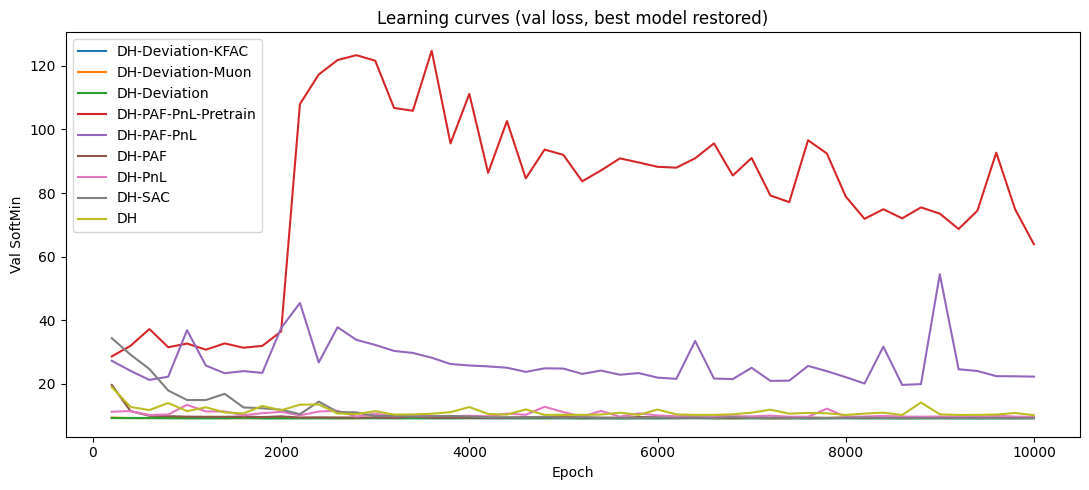

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    log = res.get('log', [])
    # фильтруем baseline (одна запись с epoch=0)
    log = [e for e in log if e.get('epoch', 0) > 0]
    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves (val loss, best model restored)')
ax.legend()
plt.tight_layout()
plt.show()

DH-Deviation-KFAC [{'epoch': 200, 'val_loss': 9.232046127319336, 'elapsed': 24.68978933803737, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 400, 'val_loss': 9.166086196899414, 'elapsed': 49.1584248659201, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 600, 'val_loss': 9.175064086914062, 'elapsed': 74.54928787518293, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 800, 'val_loss': 9.154476165771484, 'elapsed': 99.61596457008272, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1000, 'val_loss': 9.18735122680664, 'elapsed': 124.84023761609569, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1200, 'val_loss': 9.152565002441406, 'elapsed': 150.08482412109151, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1400, 'val_loss': 9.150554656982422, 'elapsed': 175.03427462512627, 'test_s

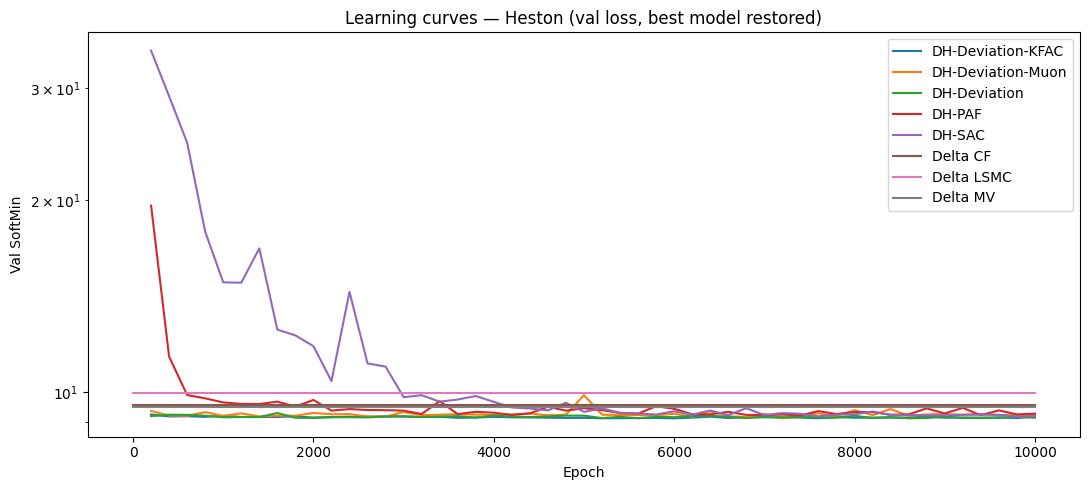

In [19]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

DH-Deviation-KFAC [{'epoch': 200, 'val_loss': 9.232046127319336, 'elapsed': 24.68978933803737, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 400, 'val_loss': 9.166086196899414, 'elapsed': 49.1584248659201, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 600, 'val_loss': 9.175064086914062, 'elapsed': 74.54928787518293, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 800, 'val_loss': 9.154476165771484, 'elapsed': 99.61596457008272, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1000, 'val_loss': 9.18735122680664, 'elapsed': 124.84023761609569, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1200, 'val_loss': 9.152565002441406, 'elapsed': 150.08482412109151, 'test_softmin': nan, 'mean_pnl': nan, 'std_pnl': nan, 'fees_mean': nan}, {'epoch': 1400, 'val_loss': 9.150554656982422, 'elapsed': 175.03427462512627, 'test_s

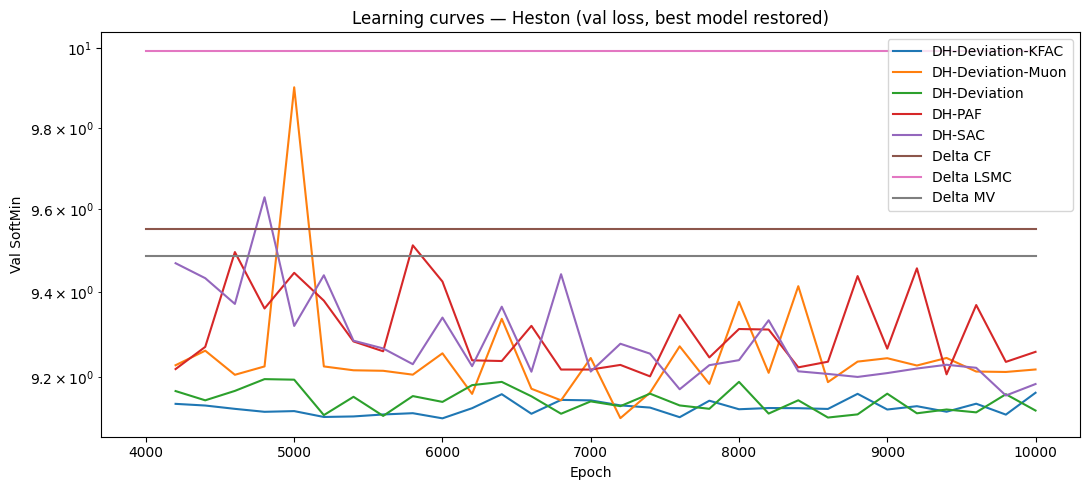

In [20]:
import copy

fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PAF-PnL-Pretrain', 'DH' , 'DH-PnL']:
        continue
    log = res.get('log', [])
    print(name, log)
    while log[-1]['epoch'] != 10000:
        tmp = copy.deepcopy(log[-1])
        tmp['epoch'] += 200
        log.append(tmp)

    log = log[20:]

    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## Results

- Deep Hedging (DH) > Delta Hedging with compatible speed on Heston
- DH > Delta Hedging on GBM (where Delta is optimal)
- PAF > No-PAF
- Adding PnL requires some tricks like predicting deviation from delta. Perhaps using true Heston Delta instead of GBM proxy would lead to better result but would require to train a full NN to predict delta.
- SAC gives improvement but they feel random unlike in DH-deviation (see plot above)
- Other improvements like K-FAC were not yet considered


---


- Overall this work is a part of my GQW and overall what I did there is more like an article and less of "article implementation", but I found no real "other RL algorithms" to compete with MCPG here, if something is worse than DH - I would just skip it.

1. Вам необходимо выбрать и реализовать алгоритм, предложенный в статье на ваш выбор, и провести ряд экспериментов из этого исследования. Учитывая ограничения на компьют и время, необязательно проводить все эксперименты, упомянутые в статье. Выберите 2 - 5 экспериментов, которые считаете наиболее релевантными, приведите аргументы, почему были выбраны именно они, и проведите их. Другие методы из статьи, с которым сравнивается основной метод, реализовывать не нужно.
2. Цель всего задания - имплементировать понравившийся алгоритм и доказать его работоспособность на каком минимальном наборе сред/бенчмарков (или наоборот, такое тоже бывает). Затем представить краткий отчет по вашим экспериментам в свободной форме и записать десятиминутное видео, в котором рассказать суть статьи, официально объявленные результаты, как они соотносятся с вашими экспериментами, и поделиться любыми другими впечатлениями и наблюдениями, которые вы сделали в процессе реализации или чтения статьи.
3. Можно объединяться в группу до 2-х человек.
4. Задание весит 25% от всей оценки за курс.
5. Дедлайн на сдачу - последнее занятие курса, 09:00, 25 марта. Сдать надо будет код (который можно запустить) и отчет в формате ipynb/pdf + видео. Авторский код использовать можно, но главное это читаемый код экспериментов, который можно было перезапустить при желании, их описание + результаты.
6. Оценка выставляется по 10-балльной шкале: 6 баллов за код и отчет + 4 балла за видео.
7. Ограничение на видео - 10 минут."		